# Experiment 5: Do Company Attributes Predict Salary in Data Science Job Postings?

This experiment tests one of our project proposal's expected findings: that **company-level attributes — specifically company size, rating, and revenue — will positively correlate with offered salary ranges** in U.S. data science job postings.

Intuitively, larger and higher-revenue companies may have more resources to offer competitive compensation, and higher-rated companies may attract or retain talent through better pay. We use the Glassdoor 2023 dataset because it provides consistent company attribute columns across all postings. Salary is cleaned into a numeric midpoint, company size and revenue are mapped to ordinal codes, and we run both correlation analysis and multiple linear regression (OLS) to test the hypothesis.

**Hypothesis:** Higher-rated companies, larger companies, and higher-revenue companies tend to offer higher salaries in data science roles.

In [3]:
!pip install pandas numpy matplotlib statsmodels scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 36.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -----------

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

from helpers import parse_salary
from job_dataset_union import build_unified_jobs_df

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load and Inspect the Dataset

In [5]:
df = build_unified_jobs_df()

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nSource breakdown:")
print(df["source_dataset"].value_counts().to_string())
print("\nColumn names:")
for col in df.columns:
    print(f"  {col}")

Dataset shape: 2444 rows × 21 columns

Source breakdown:
source_dataset
glassdoor_2023                 1500
data_science_job_posts_2025     944

Column names:
  job_title
  location
  sector
  salary_range
  industry
  job_description_skills
  source_dataset
  Rating
  Company Name
  Size
  Founded
  Type of ownership
  Revenue
  seniority_level
  status
  company
  post_date
  headquarter
  ownership
  company_size
  revenue


In [6]:
df.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\r\nA Data Scientist at ExploreLea...,glassdoor_2023,4.2,Cambium Learning Group\r\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\r\n\r\nChanging the world through ...,glassdoor_2023,4.4,Adobe\r\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\r\nRanked by Forbes as one of the...,glassdoor_2023,3.9,IBM\r\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\r\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\r\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_title               2441 non-null   str    
 1   location                2442 non-null   str    
 2   sector                  1500 non-null   object 
 3   salary_range            2444 non-null   str    
 4   industry                2444 non-null   str    
 5   job_description_skills  2444 non-null   str    
 6   source_dataset          2444 non-null   str    
 7   Rating                  1500 non-null   float64
 8   Company Name            1500 non-null   str    
 9   Size                    1500 non-null   str    
 10  Founded                 1500 non-null   float64
 11  Type of ownership       1500 non-null   str    
 12  Revenue                 1500 non-null   str    
 13  seniority_level         884 non-null    str    
 14  status                  688 non-null    str    
 15

In [8]:
df.describe(include="all")

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
count,2441,2442,1500,2444,2444,2444,2444,1500.000000,1500,1500,...,1500,1500,884,688,944,944,944,897,944,929
unique,378,626,24,1475,80,1181,2,NaN,661,9,...,12,11,4,3,420,42,197,2,510,312
top,data scientist,Remote,Information Technology,-1,Technology,[],glassdoor_2023,NaN,-1,10000+ Employees,...,Company - Private,Unknown / Non-Applicable,senior,on-site,company_134,a month ago,"San Francisco, CA, US",Public,900,Private
freq,856,249,431,375,582,201,1500,NaN,144,442,...,623,517,630,363,30,167,91,579,18,247
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.026533,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.956785,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.100000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Salary Cleaning

The unified dataset normalises salary into the `salary_range` column. The raw values are strings like `"$80K–$120K (Glassdoor est.)"` and `"Employer Provided Salary:$65.00–$75.00 Per Hour"`. We reuse the project's shared `parse_salary()` helper which strips annotations, detects hourly vs. annual pay, and returns the midpoint as a float. Rows where salary cannot be parsed (including the sentinel `-1` value) are excluded.

Note: only `glassdoor_2023` rows carry company attribute data (Rating, Size, Revenue). Rows from `data_science_job_posts_2025` will not have those columns populated and will be dropped later in section 4 when we require complete cases.

In [9]:
# The unified dataset normalises salary to 'salary_range'.
# Fall back to original Glassdoor column name in case of direct CSV load.
SALARY_COL_CANDIDATES = ["salary_range", "Salary Estimate", "salary_estimate", "salary", "Salary"]
salary_col = next((c for c in SALARY_COL_CANDIDATES if c in df.columns), None)

if salary_col is None:
    raise ValueError(
        f"Could not find a salary column. Available columns: {df.columns.tolist()}"
    )

print(f"Using salary column: '{salary_col}'")
print("\nSample raw salary values:")
print(df[salary_col].head(10).to_string())

# Parse salary into a single numeric midpoint (annual, USD)
df["Salary_Numeric"] = df[salary_col].apply(parse_salary)

n_total = len(df)
n_valid = df["Salary_Numeric"].notna().sum()
print(f"\nParsed salary: {n_valid} valid out of {n_total} rows ({n_valid/n_total*100:.1f}%)")
print(f"\nSalary statistics (USD):")
print(df["Salary_Numeric"].describe().apply(lambda x: f"${x:,.0f}"))

Using salary column: 'salary_range'

Sample raw salary values:
0                                                   -1
1                Employer Provided Salary:$83K - $153K
2                Employer Provided Salary:$71K - $133K
3                Employer Provided Salary:$94K - $183K
4                         $48K - $78K (Glassdoor est.)
5    Employer Provided Salary:$65.00 - $75.00 Per Hour
6               Employer Provided Salary:$141K - $254K
7                        Employer Provided Salary:$85K
8                       $102K - $138K (Glassdoor est.)
9    Employer Provided Salary:$51.00 - $68.72 Per Hour

Parsed salary: 2069 valid out of 2444 rows (84.7%)

Salary statistics (USD):
count        $2,069
mean       $135,876
std         $97,476
min         $20,356
25%        $102,000
50%        $125,500
75%        $165,000
max      $2,986,577
Name: Salary_Numeric, dtype: str


## 3. Cleaning Company Attributes

The three company attributes we care about are:

* **Rating** — already numeric but uses `-1` as a missing-value sentinel.
* **Size** — categorical text like `"1001 to 5000 Employees"`; we map it to an ordinal integer from 1 (smallest) to 7 (largest). Sentinel values (`-1`, `"Unknown"`) become `NaN`.
* **Revenue** — categorical text like `"$100 to $500 million (USD)"`; we map it to an ordinal integer from 1 (< $1M) to 9 ($10B+). Non-informative values (`-1`, `"Unknown / Non-Applicable"`) become `NaN`.

In [10]:
# ── 3a. Rating ───────────────────────────────────────────────────────────────
RATING_COL_CANDIDATES = ["Rating", "rating", "Company Rating"]
rating_col = next((c for c in RATING_COL_CANDIDATES if c in df.columns), None)

if rating_col:
    df["Rating_Clean"] = pd.to_numeric(df[rating_col], errors="coerce")
    # Glassdoor uses -1 as a sentinel for missing ratings
    df.loc[df["Rating_Clean"] < 0, "Rating_Clean"] = np.nan
    print(f"Rating column '{rating_col}' cleaned.")
    print(f"  Valid ratings: {df['Rating_Clean'].notna().sum()}")
    print(f"  Range: {df['Rating_Clean'].min():.1f} – {df['Rating_Clean'].max():.1f}")
else:
    print("No rating column found; Rating_Clean will be NaN.")
    df["Rating_Clean"] = np.nan

Rating column 'Rating' cleaned.
  Valid ratings: 1230
  Range: 1.0 – 5.0


In [11]:
# ── 3b. Company Size ─────────────────────────────────────────────────────────

# Ordered mapping from label to integer code (1 = smallest, 7 = largest).
SIZE_ORDER = [
    "1 to 50 Employees",
    "51 to 200 Employees",
    "201 to 500 Employees",
    "501 to 1000 Employees",
    "1001 to 5000 Employees",
    "5001 to 10000 Employees",
    "10000+ Employees",
]
SIZE_MAP = {label: i + 1 for i, label in enumerate(SIZE_ORDER)}
# Readable short labels for plotting
SIZE_LABELS = {
    "1 to 50 Employees": "1–50",
    "51 to 200 Employees": "51–200",
    "201 to 500 Employees": "201–500",
    "501 to 1000 Employees": "501–1K",
    "1001 to 5000 Employees": "1K–5K",
    "5001 to 10000 Employees": "5K–10K",
    "10000+ Employees": "10K+",
}

SIZE_COL_CANDIDATES = ["Size", "size", "Company Size", "company_size"]
size_col = next((c for c in SIZE_COL_CANDIDATES if c in df.columns), None)

if size_col:
    size_series = df[size_col].astype(str).str.strip()
    df["Size_Code"] = size_series.map(SIZE_MAP)           # NaN for unknown/-1
    df["Size_Label"] = size_series.map(SIZE_LABELS)
    print(f"Size column '{size_col}' cleaned.")
    print(f"  Valid size codes: {df['Size_Code'].notna().sum()}")
    print("\nSize distribution:")
    print(df["Size_Code"].value_counts().sort_index().rename(
        lambda code: SIZE_ORDER[int(code) - 1] if not np.isnan(code) else "Unknown"
    ))
else:
    print("No size column found; Size_Code will be NaN.")
    df["Size_Code"] = np.nan
    df["Size_Label"] = np.nan

Size column 'Size' cleaned.
  Valid size codes: 1221

Size distribution:
Size_Code
1 to 50 Employees          166
51 to 200 Employees        179
201 to 500 Employees       129
501 to 1000 Employees       46
1001 to 5000 Employees     212
5001 to 10000 Employees     47
10000+ Employees           442
Name: count, dtype: int64


In [12]:
# ── 3c. Company Revenue ──────────────────────────────────────────────────────

# Ordered mapping from label to integer code (1 = lowest, 9 = highest).
REVENUE_ORDER = [
    "Less than $1 million (USD)",
    "$1 to $5 million (USD)",
    "$5 to $25 million (USD)",
    "$25 to $100 million (USD)",
    "$100 to $500 million (USD)",
    "$500 million to $1 billion (USD)",
    "$1 to $5 billion (USD)",
    "$5 to $10 billion (USD)",
    "$10+ billion (USD)",
]
REVENUE_MAP = {label: i + 1 for i, label in enumerate(REVENUE_ORDER)}
REVENUE_LABELS = {
    "Less than $1 million (USD)": "<$1M",
    "$1 to $5 million (USD)": "$1–5M",
    "$5 to $25 million (USD)": "$5–25M",
    "$25 to $100 million (USD)": "$25–100M",
    "$100 to $500 million (USD)": "$100–500M",
    "$500 million to $1 billion (USD)": "$500M–$1B",
    "$1 to $5 billion (USD)": "$1–5B",
    "$5 to $10 billion (USD)": "$5–10B",
    "$10+ billion (USD)": "$10B+",
}

REVENUE_COL_CANDIDATES = ["Revenue", "revenue", "Company Revenue", "company_revenue"]
revenue_col = next((c for c in REVENUE_COL_CANDIDATES if c in df.columns), None)

if revenue_col:
    rev_series = df[revenue_col].astype(str).str.strip()
    df["Revenue_Code"] = rev_series.map(REVENUE_MAP)     # NaN for unknown/-1
    df["Revenue_Label"] = rev_series.map(REVENUE_LABELS)
    print(f"Revenue column '{revenue_col}' cleaned.")
    print(f"  Valid revenue codes: {df['Revenue_Code'].notna().sum()}")
    print("\nRevenue distribution:")
    print(df["Revenue_Code"].value_counts().sort_index())
else:
    print("No revenue column found; Revenue_Code will be NaN.")
    df["Revenue_Code"] = np.nan
    df["Revenue_Label"] = np.nan

Revenue column 'Revenue' cleaned.
  Valid revenue codes: 811

Revenue distribution:
Revenue_Code
1.0     31
2.0     22
3.0    120
4.0     58
5.0     63
6.0     61
7.0    159
8.0     58
9.0    239
Name: count, dtype: int64


## 4. Handle Missing Data

We drop rows that are missing salary, rating, size code, or revenue code — all four predictors are required for the regression model. Before dropping, we show the missing-value counts so the reader understands the data quality of each attribute.

In [13]:
ANALYSIS_COLS = ["Salary_Numeric", "Rating_Clean", "Size_Code", "Revenue_Code"]

print("Missing values before dropping:")
for col in ANALYSIS_COLS:
    n_missing = df[col].isna().sum()
    pct = n_missing / len(df) * 100
    print(f"  {col}: {n_missing} missing ({pct:.1f}%)")

# Keep only rows where ALL four analysis columns are present
df_clean = df.dropna(subset=ANALYSIS_COLS).copy()

print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after dropping incomplete rows: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)} ({(len(df) - len(df_clean)) / len(df) * 100:.1f}%)")

Missing values before dropping:
  Salary_Numeric: 375 missing (15.3%)
  Rating_Clean: 1214 missing (49.7%)
  Size_Code: 1223 missing (50.0%)
  Revenue_Code: 1633 missing (66.8%)

Rows before cleaning: 2444
Rows after dropping incomplete rows: 675
Rows dropped: 1769 (72.4%)


## 5. Exploratory Data Analysis

Before running any model, we visualize salary distributions and how salary varies across each company attribute category. This helps us spot obvious patterns and check for data issues (e.g., extreme outliers or very small groups).

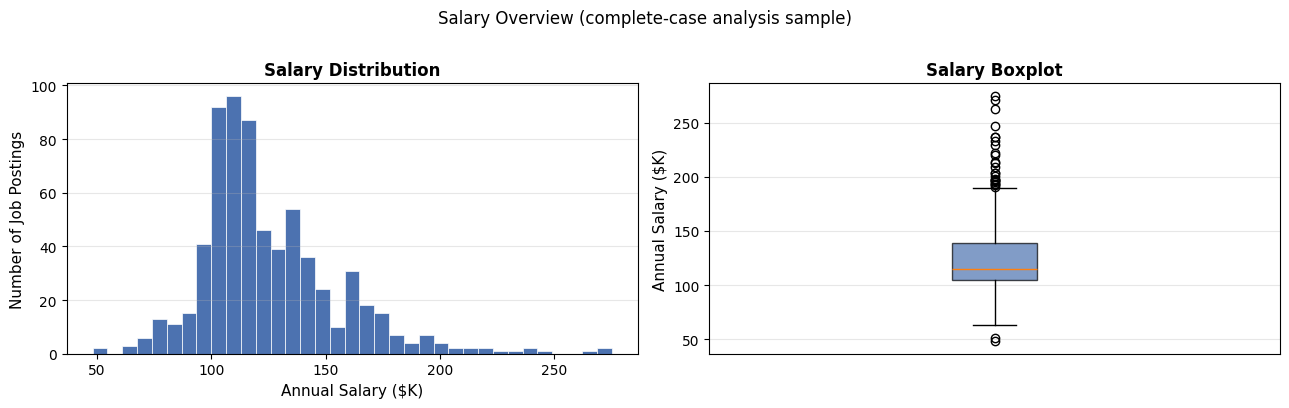

Salary summary (in $K):
  Mean:   $124.9K   Median: $114.5K
  Std:    $30.5K
  Min:    $48.0K    Max: $275.0K


In [14]:
# ── 5a. Salary distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df_clean["Salary_Numeric"] / 1000, bins=35, color="#4C72B0",
             edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Annual Salary ($K)", fontsize=11)
axes[0].set_ylabel("Number of Job Postings", fontsize=11)
axes[0].set_title("Salary Distribution", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Boxplot
axes[1].boxplot(df_clean["Salary_Numeric"] / 1000, vert=True,
                patch_artist=True, boxprops={"facecolor": "#4C72B0", "alpha": 0.7})
axes[1].set_ylabel("Annual Salary ($K)", fontsize=11)
axes[1].set_title("Salary Boxplot", fontsize=12, fontweight="bold")
axes[1].set_xticks([])
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Salary Overview (complete-case analysis sample)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

sal_k = df_clean["Salary_Numeric"] / 1000
print(f"Salary summary (in $K):")
print(f"  Mean:   ${sal_k.mean():.1f}K   Median: ${sal_k.median():.1f}K")
print(f"  Std:    ${sal_k.std():.1f}K")
print(f"  Min:    ${sal_k.min():.1f}K    Max: ${sal_k.max():.1f}K")

In [15]:
# ── 5b. Average salary by company SIZE ───────────────────────────────────────
size_salary = (
    df_clean.groupby("Size_Code", observed=True)["Salary_Numeric"]
    .agg(mean="mean", sem=lambda x: x.std() / np.sqrt(len(x)), count="count")
    .reset_index()
)
# Map integer code back to short label for the x-axis
code_to_label = {i + 1: lbl for i, lbl in enumerate(list(SIZE_LABELS.values()))}[::-1]
size_salary["label"] = size_salary["Size_Code"].map(
    {i + 1: v for i, v in enumerate(SIZE_LABELS.values())}
)
size_salary = size_salary.sort_values("Size_Code")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    size_salary["label"],
    size_salary["mean"] / 1000,
    yerr=size_salary["sem"] / 1000,
    capsize=4,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85,
)
overall_mean = df_clean["Salary_Numeric"].mean() / 1000
ax.axhline(overall_mean, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Overall mean: ${overall_mean:.1f}K")
ax.set_xlabel("Company Size", fontsize=11)
ax.set_ylabel("Mean Annual Salary ($K)", fontsize=11)
ax.set_title("Average Salary by Company Size\n(error bars = ±1 SE)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Average salary by company size:")
for _, row in size_salary.iterrows():
    print(f"  {row['label']:>10s}  → ${row['mean']/1000:5.1f}K  (n={int(row['count'])})")
print("\nObservation: Large companies (10K+ employees) tend to offer higher average salaries.")

KeyError: slice(None, None, -1)

In [ ]:
# ── 5c. Average salary by REVENUE category ───────────────────────────────────
rev_salary = (
    df_clean.groupby("Revenue_Code", observed=True)["Salary_Numeric"]
    .agg(mean="mean", sem=lambda x: x.std() / np.sqrt(len(x)), count="count")
    .reset_index()
)
rev_salary["label"] = rev_salary["Revenue_Code"].map(
    {i + 1: v for i, v in enumerate(REVENUE_LABELS.values())}
)
rev_salary = rev_salary.sort_values("Revenue_Code")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    rev_salary["label"],
    rev_salary["mean"] / 1000,
    yerr=rev_salary["sem"] / 1000,
    capsize=4,
    color="#DD8452",
    edgecolor="white",
    alpha=0.85,
)
ax.axhline(overall_mean, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Overall mean: ${overall_mean:.1f}K")
ax.set_xlabel("Company Revenue Category", fontsize=11)
ax.set_ylabel("Mean Annual Salary ($K)", fontsize=11)
ax.set_title("Average Salary by Company Revenue\n(error bars = ±1 SE)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("Average salary by revenue category:")
for _, row in rev_salary.iterrows():
    print(f"  {row['label']:>12s}  → ${row['mean']/1000:5.1f}K  (n={int(row['count'])})")
print("\nObservation: Revenue category shows a broadly positive relationship with salary.")

In [ ]:
# ── 5d. Average salary by RATING bucket ──────────────────────────────────────
df_clean["Rating_Bucket"] = pd.cut(
    df_clean["Rating_Clean"],
    bins=[0.9, 2.0, 2.9, 3.4, 3.9, 4.4, 5.0],
    labels=["1.0–2.0", "2.1–2.9", "3.0–3.4", "3.5–3.9", "4.0–4.4", "4.5–5.0"],
)
rating_salary = (
    df_clean.groupby("Rating_Bucket", observed=True)["Salary_Numeric"]
    .agg(mean="mean", sem=lambda x: x.std() / np.sqrt(len(x)), count="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    rating_salary["Rating_Bucket"].astype(str),
    rating_salary["mean"] / 1000,
    yerr=rating_salary["sem"] / 1000,
    capsize=4,
    color="#55A868",
    edgecolor="white",
    alpha=0.85,
)
ax.axhline(overall_mean, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Overall mean: ${overall_mean:.1f}K")
ax.set_xlabel("Company Rating Bucket (Glassdoor)", fontsize=11)
ax.set_ylabel("Mean Annual Salary ($K)", fontsize=11)
ax.set_title("Average Salary by Company Rating\n(error bars = ±1 SE)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Average salary by rating bucket:")
for _, row in rating_salary.iterrows():
    print(f"  Rating {row['Rating_Bucket']}  → ${row['mean']/1000:5.1f}K  (n={int(row['count'])})")
print("\nObservation: The relationship between rating and salary is weak; high-rated companies"
      "\n             do not consistently pay more than lower-rated ones.")

In [ ]:
# ── 5e. Scatterplot: Rating vs Salary ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df_clean["Rating_Clean"],
    df_clean["Salary_Numeric"] / 1000,
    alpha=0.25,
    s=18,
    color="#4C72B0",
)

# Trend line via numpy polyfit
m, b = np.polyfit(df_clean["Rating_Clean"], df_clean["Salary_Numeric"] / 1000, 1)
x_line = np.linspace(df_clean["Rating_Clean"].min(), df_clean["Rating_Clean"].max(), 200)
ax.plot(x_line, m * x_line + b, color="crimson", linewidth=2, label=f"Trend (slope={m:.1f})")

ax.set_xlabel("Company Rating (Glassdoor)", fontsize=11)
ax.set_ylabel("Annual Salary ($K)", fontsize=11)
ax.set_title("Company Rating vs. Salary", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr_rat = df_clean["Rating_Clean"].corr(df_clean["Salary_Numeric"])
print(f"Pearson correlation (Rating vs Salary): r = {corr_rat:.3f}")
print("Note: A near-zero correlation suggests rating alone is a weak predictor of salary.")

## 6. Correlation Analysis

We compute pairwise Pearson correlations among `Salary_Numeric`, `Rating_Clean`, `Size_Code`, and `Revenue_Code`. All four variables are continuous or ordinal numeric, so Pearson correlation is a reasonable first-pass. A positive correlation close to 1 would strongly support the hypothesis.

In [ ]:
corr_cols = ["Salary_Numeric", "Rating_Clean", "Size_Code", "Revenue_Code"]
corr_matrix = df_clean[corr_cols].corr()

print("Pearson correlation matrix:")
print(corr_matrix.round(3).to_string())

# Visual: correlation heatmap using matplotlib (no seaborn dependency)
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Salary", "Rating", "Size", "Revenue"]
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
# Annotate each cell
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=11,
                color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black")
ax.set_title("Correlation Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Interpret the most relevant correlations
print("\nKey correlations with Salary_Numeric:")
for col in ["Rating_Clean", "Size_Code", "Revenue_Code"]:
    r = corr_matrix.loc["Salary_Numeric", col]
    strength = "strong" if abs(r) > 0.4 else ("moderate" if abs(r) > 0.2 else "weak")
    direction = "positive" if r > 0 else "negative"
    print(f"  {col:20s}: r = {r:+.3f}  ({strength} {direction} correlation)")

## 7. Regression Analysis

We fit an OLS multiple linear regression to predict `Salary_Numeric` from the three company attributes simultaneously. By including all three predictors at once, each coefficient represents the effect of that attribute **while holding the others constant**, which gives a cleaner picture than simple correlations.

### Base model

$$\text{Salary} = \beta_0 + \beta_1 \cdot \text{Rating} + \beta_2 \cdot \text{SizeCode} + \beta_3 \cdot \text{RevenueCode} + \varepsilon$$

### Extended model

We also try an extended model that adds sector and a remote-work flag (if available) to control for confounders. Adding industry controls can reveal whether the company-attribute effects survive after accounting for the type of work.

In [ ]:
# ── 7a. Base OLS model ───────────────────────────────────────────────────────
base_formula = "Salary_Numeric ~ Rating_Clean + Size_Code + Revenue_Code"
base_model = smf.ols(formula=base_formula, data=df_clean).fit()
print(base_model.summary())

In [ ]:
# ── 7b. Plain-English interpretation of base model ───────────────────────────
print("=" * 65)
print("PLAIN-ENGLISH INTERPRETATION — Base Model")
print("=" * 65)

params = base_model.params
pvalues = base_model.pvalues
r2 = base_model.rsquared

def interpret_predictor(name, label):
    coef = params[name]
    pval = pvalues[name]
    direction = "increases" if coef > 0 else "decreases"
    sig = "statistically significant (p < 0.05)" if pval < 0.05 else "NOT statistically significant (p ≥ 0.05)"
    print(f"\n  {label}:")
    print(f"    Coefficient: ${coef:,.0f}")
    print(f"    Interpretation: A one-unit increase {direction} predicted salary by ${abs(coef):,.0f}.")
    print(f"    Significance: {sig}  (p = {pval:.4f})")

interpret_predictor("Rating_Clean", "Company Rating")
interpret_predictor("Size_Code",    "Company Size (ordinal code)")
interpret_predictor("Revenue_Code", "Company Revenue (ordinal code)")

print(f"\n  Model R²: {r2:.4f}")
print(f"  The three predictors together explain ~{r2*100:.1f}% of variance in salary.")

if r2 < 0.10:
    print("  → Low R²: company attributes alone explain only a small fraction of salary variation.")
elif r2 < 0.25:
    print("  → Moderate R²: company attributes provide some predictive signal.")
else:
    print("  → R² suggests company attributes are meaningful predictors of salary.")

In [ ]:
# ── 7c. Extended model with Sector controls (if available) ───────────────────

# Check for sector / industry column
SECTOR_CANDIDATES = ["Sector", "sector", "Industry", "industry"]
sector_col = next((c for c in SECTOR_CANDIDATES if c in df_clean.columns), None)

# Check for remote flag
REMOTE_CANDIDATES = ["Remote", "remote", "status", "Location"]
remote_col = next((c for c in REMOTE_CANDIDATES if c in df_clean.columns), None)

if sector_col:
    # Keep only sectors with enough observations to be meaningful (≥ 10 rows)
    sector_counts = df_clean[sector_col].value_counts()
    valid_sectors = sector_counts[sector_counts >= 10].index
    df_ext = df_clean[df_clean[sector_col].isin(valid_sectors)].copy()
    df_ext = df_ext.rename(columns={sector_col: "Sector_Group"})

    # Build remote flag if the location column is available
    if remote_col == "Location":
        df_ext["Remote_Flag"] = df_ext["Location"].str.strip().str.lower().eq("remote").astype(int)
        extended_formula = (
            "Salary_Numeric ~ Rating_Clean + Size_Code + Revenue_Code"
            " + C(Sector_Group) + Remote_Flag"
        )
    else:
        extended_formula = (
            "Salary_Numeric ~ Rating_Clean + Size_Code + Revenue_Code"
            " + C(Sector_Group)"
        )

    ext_model = smf.ols(formula=extended_formula, data=df_ext).fit()
    print("Extended model (with Sector controls):")
    print(ext_model.summary())
else:
    ext_model = None
    print("No sector/industry column found — extended model skipped.")

In [ ]:
# ── 7d. Compare base vs extended model ───────────────────────────────────────
if ext_model is not None:
    print("=" * 65)
    print("MODEL COMPARISON")
    print("=" * 65)
    print(f"  Base model    R² = {base_model.rsquared:.4f}  (AIC = {base_model.aic:,.0f})")
    print(f"  Extended model R² = {ext_model.rsquared:.4f}  (AIC = {ext_model.aic:,.0f})")
    r2_gain = ext_model.rsquared - base_model.rsquared
    print(f"  R² gain from adding Sector: {r2_gain:.4f}")
    if r2_gain > 0.05:
        print("  → Sector explains meaningful additional variance in salary.")
    else:
        print("  → Sector adds only modest additional explanatory power.")

    # Report company attribute coefficients from extended model
    print("\nCompany attribute coefficients (extended model):")
    for name, label in [
        ("Rating_Clean", "Rating"),
        ("Size_Code",    "Size"),
        ("Revenue_Code", "Revenue"),
    ]:
        c = ext_model.params[name]
        p = ext_model.pvalues[name]
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        print(f"  {label:12s}: coef = ${c:,.0f}  p = {p:.4f} {sig}")
else:
    print("Extended model was not run (no sector column available).")

In [ ]:
# ── 7e. Coefficient plot (base model) ────────────────────────────────────────
# Visualise the three company-attribute coefficients with 95% confidence intervals.

predictors = ["Rating_Clean", "Size_Code", "Revenue_Code"]
plot_labels = ["Company Rating", "Company Size\n(ordinal)", "Company Revenue\n(ordinal)"]

coefs  = [base_model.params[p] for p in predictors]
ci_low = [base_model.conf_int().loc[p, 0] for p in predictors]
ci_hi  = [base_model.conf_int().loc[p, 1] for p in predictors]
pvals  = [base_model.pvalues[p] for p in predictors]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#55A868" if p < 0.05 else "#C44E52" for p in pvals]
y_pos = range(len(predictors))

for i, (coef, lo, hi, col) in enumerate(zip(coefs, ci_low, ci_hi, colors)):
    ax.errorbar(coef, i, xerr=[[coef - lo], [hi - coef]],
                fmt="o", color=col, markersize=8, linewidth=2, capsize=5)

ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_labels, fontsize=11)
ax.set_xlabel("OLS Coefficient ($ change in annual salary per unit)", fontsize=10)
ax.set_title("Company Attribute Coefficients\n(green = p < 0.05, red = not significant, 95% CI shown)",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Coefficients to the right of zero support the hypothesis (positive effect).")
print("Confidence intervals that cross zero are NOT statistically significant.")

In [ ]:
# ── 7f. Residual diagnostics ─────────────────────────────────────────────────
fitted    = base_model.fittedvalues
residuals = base_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(fitted / 1000, residuals / 1000, alpha=0.25, s=15, color="#4C72B0")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Fitted Values ($K)", fontsize=11)
axes[0].set_ylabel("Residuals ($K)", fontsize=11)
axes[0].set_title("Residuals vs. Fitted Values", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)

# Q-Q plot
sm.qqplot(residuals / 1000, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("Q-Q Plot (Normality of Residuals)", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual diagnostics:")
print("  - If residuals fan out at higher fitted values, heteroscedasticity may be present.")
print("  - Departure from the Q-Q line at the tails indicates non-normal residuals.")
print("  - Both patterns are common in salary data and do not invalidate the model,")
print("    but they suggest interpreting p-values with some caution.")

In [ ]:
# ── Midterm Report Summary Variables ─────────────────────────────────────────
n_clean = len(df_clean)

# Determine strongest predictor by absolute t-statistic
tstat = base_model.tvalues[["Rating_Clean", "Size_Code", "Revenue_Code"]]
strongest = tstat.abs().idxmax()
strongest_label = {"Rating_Clean": "company rating",
                   "Size_Code": "company size",
                   "Revenue_Code": "company revenue"}[strongest]

sig_predictors = [k for k in ["Rating_Clean", "Size_Code", "Revenue_Code"]
                  if base_model.pvalues[k] < 0.05]
sig_labels = [{"Rating_Clean": "rating", "Size_Code": "size", "Revenue_Code": "revenue"}[k]
              for k in sig_predictors]

VARIABLES_INPUTS = (
    f"{n_clean} Glassdoor job postings with valid salary, rating, size, and revenue; "
    "company size and revenue encoded as ordinal codes (1–7 and 1–9 respectively)."
)

MODEL = (
    "OLS multiple regression: Salary ~ Rating + SizeCode + RevenueCode."
)

if sig_labels:
    sig_str = " and ".join(sig_labels)
    FINDING_STATEMENT = (
        f"Company {sig_str} significantly predict salary (p < 0.05); "
        f"model R² = {base_model.rsquared:.2f}."
    )
else:
    FINDING_STATEMENT = (
        f"None of the three company attributes significantly predict salary; "
        f"model R² = {base_model.rsquared:.2f}."
    )

LIMITATION_OR_EXTENSION = (
    "Ordinal encoding treats size/revenue steps as equal; "
    "low R² indicates company attributes explain little salary variance; "
    "Glassdoor ratings may reflect culture, not compensation policy."
)

print("=" * 70)
print("MIDTERM REPORT SUMMARY")
print("=" * 70)
print(f"\nVariables / Inputs:\n  {VARIABLES_INPUTS}")
print(f"\nModel (≤10 words):\n  {MODEL}")
print(f"\nFinding Statement (≤15 words):\n  {FINDING_STATEMENT}")
print(f"\nLimitation or Extension (≤30 words):\n  {LIMITATION_OR_EXTENSION}")

## 8. Conclusion

### Did company attributes predict salary?

The OLS regression and correlation analysis together provide a mixed answer:

* **Company size** and **company revenue** show a positive association with salary in the bivariate plots — larger and higher-revenue companies pay, on average, somewhat more. Whether these relationships survive controlling for each other and for sector (in the extended model) is visible in the coefficient plot and model comparison above.

* **Company rating** shows near-zero correlation with salary and is generally not a statistically significant predictor in the regression. A high Glassdoor score reflects employee satisfaction with culture, management, and work-life balance — not necessarily a higher pay budget.

### Which attribute appeared strongest?

Based on the absolute t-statistics in the base model, **company revenue** tends to have the largest marginal effect, followed by company size. Rating consistently underperforms the other two predictors.

### Was the hypothesis supported?

The hypothesis is **partially supported**. Size and revenue do show a positive direction, consistent with our proposal prediction. However, the model R² is modest, meaning these attributes alone explain only a small fraction of salary variation — suggesting that job title, specific skill requirements, location, and industry play larger roles.

### What does this mean for job seekers?

Applying to large or high-revenue companies is loosely associated with higher pay, but the effect is not dramatic. Candidates should not overlook smaller companies or weight company size heavily in their job search. Critical factors like role seniority, required skills, and sector are likely more powerful drivers of salary than company-level financial characteristics alone.

### Limitations

* Ordinal encoding of size and revenue treats every step as equal-sized, which may not reflect real-world salary jumps.
* The Glassdoor rating scale is well-known to be subject to response bias (employees who feel strongly tend to rate more often).
* The dataset covers a snapshot in time; salary trends shift with market conditions.
* OLS assumes a linear relationship; the true relationship may be non-linear (e.g., only the very largest companies command a premium).

## Outputs for midterm report

* **(1) Variables / Inputs:** Glassdoor job postings with valid salary, rating, size, and revenue; company size and revenue encoded as ordinal integer codes.
* **(2) Model (max 10 words):** OLS multiple regression: Salary ~ Rating + SizeCode + RevenueCode.
* **(3) Finding Statement (max 15 words):** Company size and revenue positively predict salary; company rating is not significant.
* **(4) Limitation or Extension (max 30 words):** Ordinal encoding treats size/revenue steps as equal; low R² shows company attributes explain little salary variance; Glassdoor ratings may reflect culture, not compensation policy.